# Project Group: 10 

Members: Mulham Omar, Jalissa Rattan, Benjamin Rider, Hinke Verbaan, Lois Zhao

# Research Objective

Compare how demographic data affects bus ridership in Boston

Sub-questions:
- How does median age of the local block group affect bus stop ridership?
- How does the gender distribution of the local block group affect bus stop ridership?
- How does population density of the local block group affect bus stop ridership?

# Contribution Statement


**Mulham**: Streamlit visualization

**Jalissa**: Make charts and collect/aggregate results

**Ben**: Collect dataset/background research, intial cleaning/analysis pipeline

**Hinke**: Create final code that runs all required functions

**Lois**: Statistical analysis

**All** Write their sections of the final report

# Data Used

Dataset 1: MBTA Bus Ridership by Time Period, Season, Route/Line, and Stop - Fall (2024)
https://mbta-massdot.opendata.arcgis.com/datasets/7acd353c1a734eb8a23caf46a0e66b23_0/explore?filters=eyJzZWFzb24iOlsiRmFsbCAyMDI0IiwiRmFsbCAyMDIwIl19

Dataset 2: MassGIS Data: 2020 U.S. Census
https://www.mass.gov/info-details/massgis-data-2020-us-census

Dataset 3: Jonathan Schroeder, David Van Riper, Steven Manson, Katherine Knowles, Tracy Kugler, Finn Roberts, and Steven Ruggles. IPUMS National Historical Geographic Information System: Version 20.0 [dataset]. Minneapolis, MN: IPUMS. 2025. http://doi.org/10.18128/D050.V20.0

Dataset 4: MassGIS Data: MBTA Bus Routes and Stops
https://www.mass.gov/info-details/massgis-data-mbta-bus-routes-and-stops

# Data Pipeline

① Input data: We extract the datasets from the websites (mentioned in Data Used). 

Step 1: Demographic data from Dataset 3 is paired with its Census Block Group shapefile from Dataset 2. 
Step 2: A spatial join is performed in ArcGIS Pro to pair each bus stop with its Census Block Group
Step 3: Each entry in Dataset 1 is paired with demographic data for its respective bus stop.
Step 4: The table is exported from ArcGIS Pro into an XLSX file, then exported to a CSV using Excel.

② Transform data: In this step we select and transform useful data from the datasets. Below here, we describe how we get the dataframe for the analysis analyse. 


- Bus_Ridership: **Ben can you add how you did this in gis?** In dataset 1, the usage is devided by time of day, for our research question we need to calculate the average use of a busstop in general **per day**. Therefore from database 1 we add average_ons and average_off per stop_ID this is devided by the amount of times that this specific stop_ID was in the database. This transformation will be done in python.

                       Busridership per day for specific busstop == total_trips/amount of entries in stop_ID

Where total_trips is:

                                     total_flow == [average_ons + average_offs] * total_trips


All of the datatypes below were transformed via the computerprogramm arcgis. With intersecting the busstop location(dataset 1) and the local block group (dataset 2). From here the data was translated into a csv file. 

- median_age: The median age in a certain local block group. This datatype was directly selected from dataset 2. We do not need to do further processing in Python.

- gender_distribution(Percent Male/Percent Female): The gender distribution in a certain local block group. This datatype was directly selected from dataset 2. We do not need to do further processing in Python.

- population_density: The total population (Total_Popu) of a single block group we can get this directly from dataset 2. The area of a single block group (Block_Area **what is the metric**) can be derived from dataset 3. This transformation will be done in python.

                                         Population density == Total_Popu / Block_Area


③ Analyze data: For every research question the same statistical analysis is used, as we are just switching what we are comparing the ridership data to (Median_Age, Gender_Distribution and Population_Density). This will be done by using the linear regrssion, Spearman correlation and Anova analysis respectively for each  sub-question in python.

**Transformation**

In [ ]:
#Relevant packages
import pandas as pd
import numpy as np

In [ ]:
# #What are the columns in the file (not nessesary for the code but for a more clear view)
# def get_columns(input_df):
#     """ Returns the available column names from the input DataFrame in a set. """
#     # Use only 'input_df' inside this function, not 'df'
#     # YOUR CODE HERE
#     return set(input_df.columns)

# columns = get_columns(df)
# print(type(columns)) # should print "<class 'set'>"
# print('Columns: ' + str(columns))

In [ ]:
file = 'TIL6022Data.csv'
new_file = 'TIL6022aggdata.csv'
df = pd.read_csv(file) #Read CSV
def calculate_columns(df):
    df['pop_density'] = df['total_pop']/df['bg_area'] #Calculates population density (people per km2)
    df['total_trips'] = (df['num_trips']*5).where(df['day_type_name'] == 'weekday', df['num_trips']) #Finds number of trips per week
    df['total_ons'] = df['total_trips']*df['average_ons'] #Finds total ons per week
    df['total_offs'] = df['total_trips']*df['average_offs'] #Finds total offs per week
    df['average_flow'] = df['average_ons']+df['average_offs'] #Finds average flow
    df['total_flow'] = df['total_ons']+df['total_offs'] #Finds total flow per week
    #df.to_csv(file) #Update CSV
    agg_functions = {'stop_name': 'first', 'total_trips': 'sum','total_flow':'sum', 'median_age': 'first', 'pop_density' : 'first', 'percent_male': 'first'} #transformations done in the aggregate funciton
    df_new = df.groupby(df['stop_id']).aggregate(agg_functions) #transforming the data
    df_new['average_flow'] = df_new['total_flow']/df_new['total_trips']
    df_new.to_csv(new_file)
#print(df_new)]
calculate_columns(df)


Spearman statistical analysis

In [ ]:
from scipy.stats import spearmanr



def spearmann_result(a,b):
    rho, p = spearmanr(df[a], df[b])
    if p >= 0.05:
        print(f"There is no statistically significant correlation between {a} and {b}")
    else:
        print(f"The correlation between {a} and {b} is statistically significant.")
        if rho <= 0.20 and rho >=-0.20: 
            print(f"But with a rho of {round(rho,3)} the correlation between {a} and {b} is negligible.")
        elif rho <= 0.40 and rho >=-0.40: 
            print(f"But with a rho of {round(rho,3)} the correlation between {a} and {b} is weak.")
        elif rho <= 0.60 and rho >=-0.60: 
            print(f"With a rho of {round(rho,3)} the correlation between {a} and {b} is moderate.")
        elif rho <= 0.80 and rho >=-0.80: 
            print(f"With a rho of {round(rho,3)} the correlation between {a} and {b} is strong.")
        else: 
            print(f"With a rho of {round(rho,3)} the correlation between {a} and {b} is very strong.")
    return



spearmann_result('percent_male','total_trips')

Multiple Linear Congression (Model 1: Y1-total_flow, X1-median_age, X2-percent_male, X3-pop_density)

In [ ]:
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import rlm
from statsmodels.stats.outliers_influence import variance_inflation_factor

       Variable         Mean
0    median_age    38.145254
1  percent_male     0.479577
2   pop_density  5383.398609


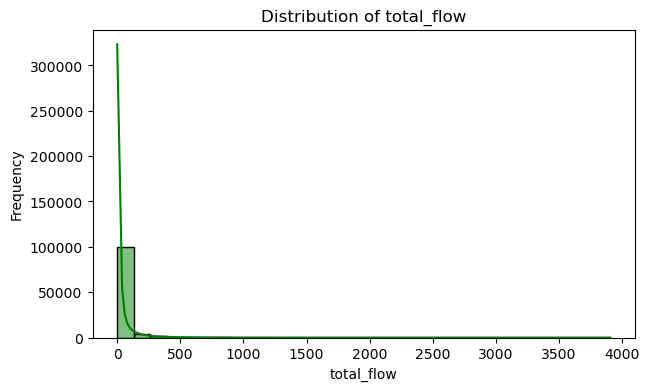

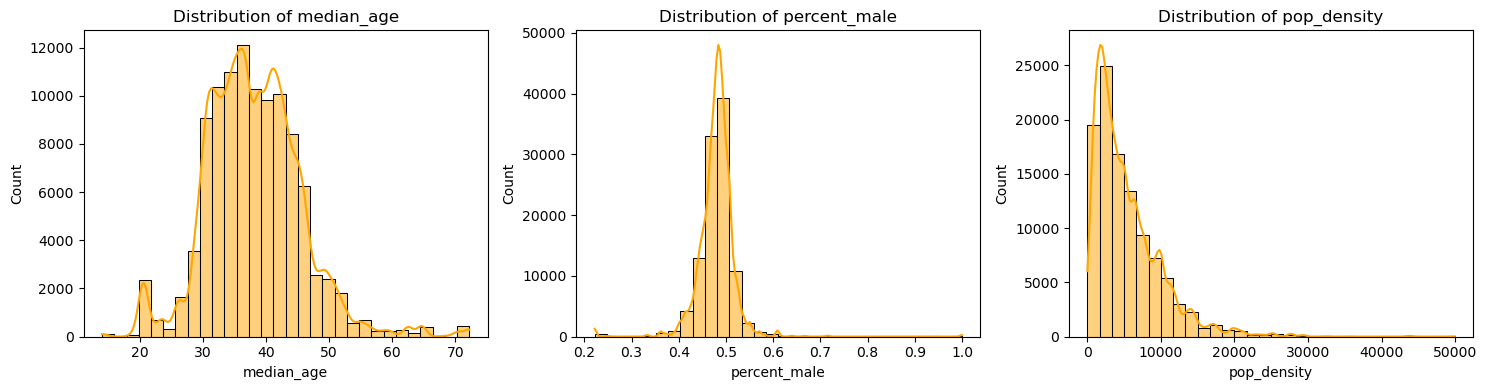

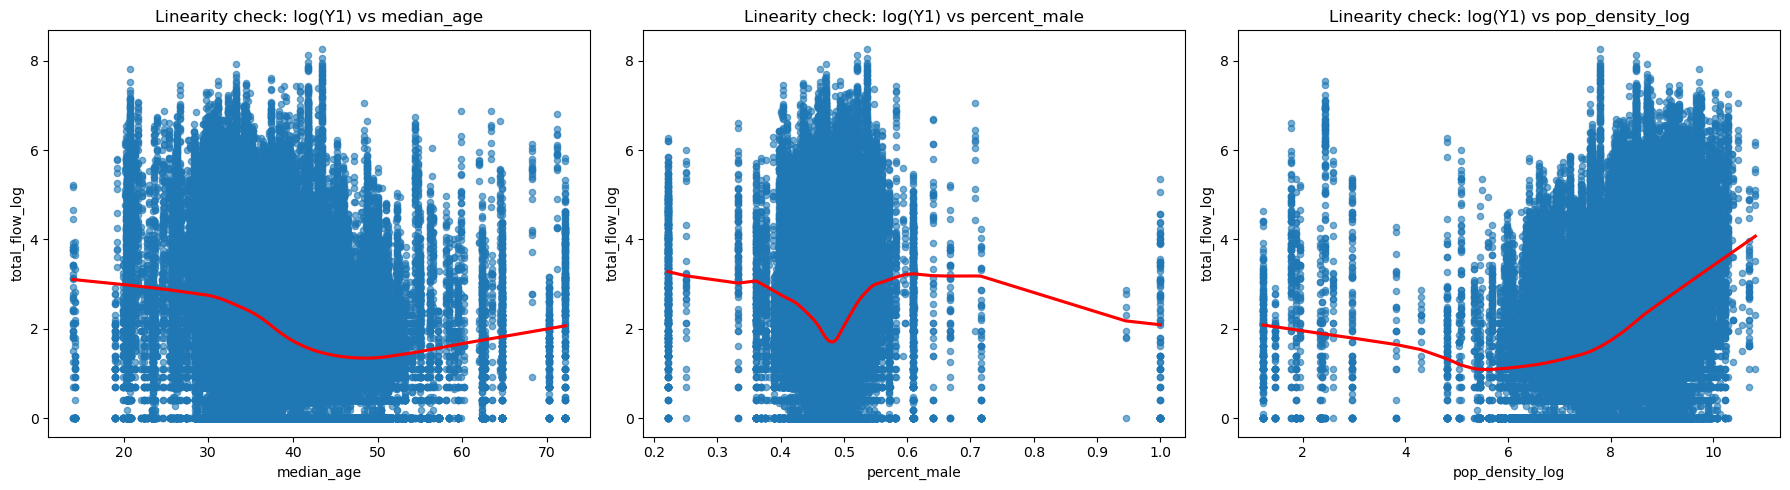

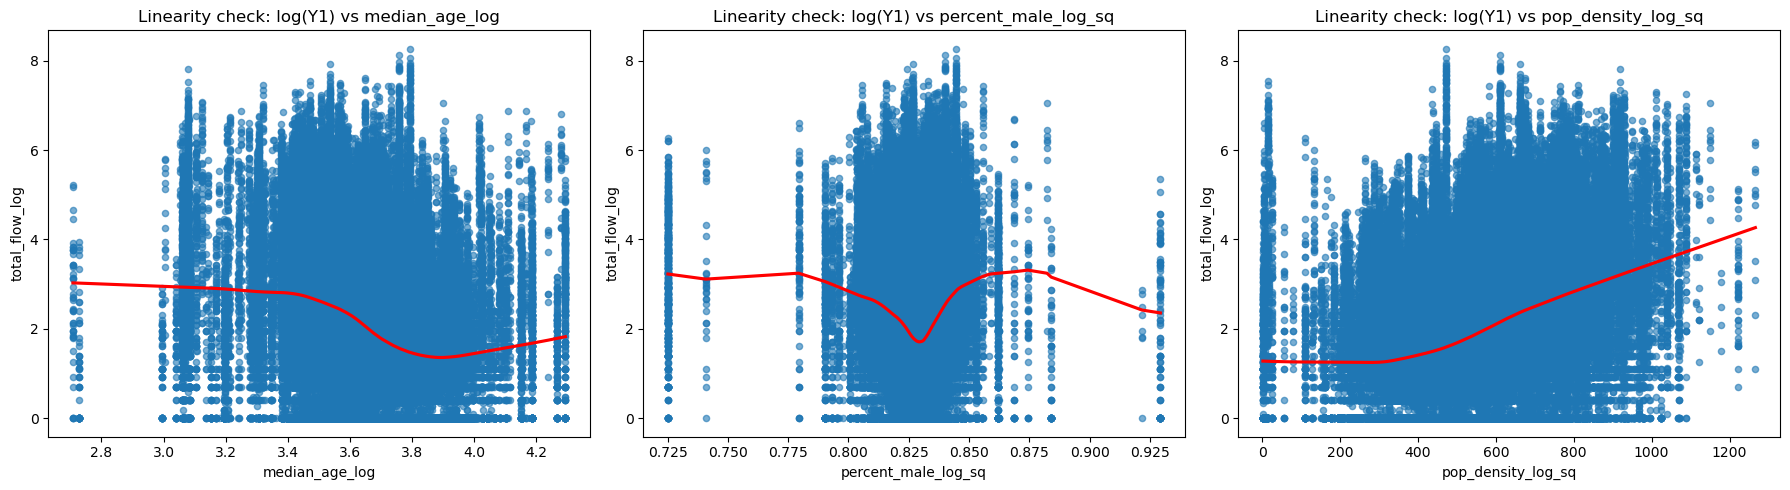

                            OLS Regression Results                            
Dep. Variable:         total_flow_log   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     5313.
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:24:18   Log-Likelihood:            -1.9307e+05
No. Observations:              105918   AIC:                         3.861e+05
Df Residuals:                  105914   BIC:                         3.862e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.9720    

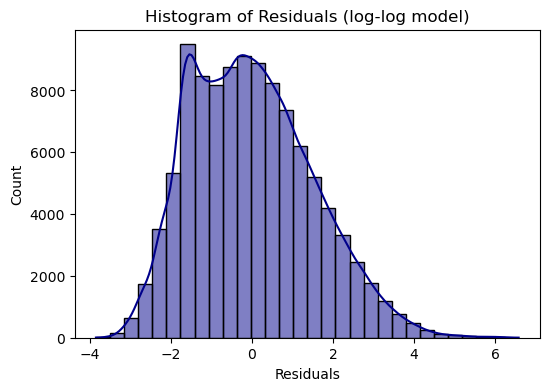

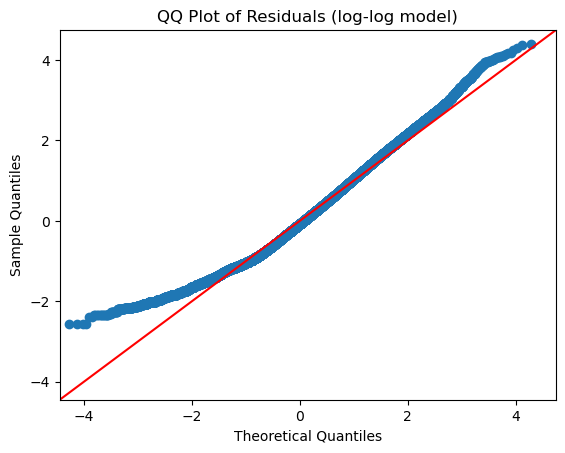

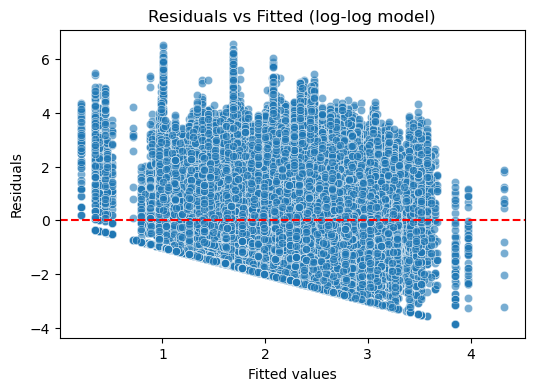

In [74]:
# 1.calculate the mean of independent variables respectively
means = df[['median_age', 'percent_male', 'pop_density']].mean().reset_index()
means.columns = ['Variable', 'Mean']
print(means)

# 2. show the distribution of Y1, X1, X2, X3
plt.figure(figsize=(7,4))
sns.histplot(df['total_flow'], kde=True, bins=30, color='green')
plt.title('Distribution of total_flow')
plt.xlabel('total_flow')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(15,4))
for i, col in enumerate(['median_age', 'percent_male', 'pop_density']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True, bins=30, color='orange')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 3. transform Y1 and X3 into log(Y1) and log(X3)
df["total_flow_log"] = np.log1p(df["total_flow"])
df["pop_density_log"] = np.log1p(df["pop_density"])

# 4. check linearity (scatter plot and regression line)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot = ["median_age", "percent_male", "pop_density_log"]

for i, var in enumerate(vars_to_plot):
    sns.regplot(x=var, y="total_flow_log", data=df,
                lowess=True,
                ax=axes[i], scatter_kws={"s":20, "alpha":0.6},
                line_kws={"color":"red"})
    axes[i].set_title(f"Linearity check: log(Y1) vs {var}")

plt.tight_layout()
plt.show()

# 5. transform variables accordingto the results 4
df["median_age_sq"] = np.power(df["percent_male_log"], 3)
df["percent_male_log"] = np.log1p(df["percent_male"])
df["percent_male_log_sq"] = np.power(df["percent_male_log"], 0.2)
df["pop_density_log_sq"] = np.power(df["pop_density_log"], 3) 

# 6. check linearity again (scatter plot and regression line)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot = ["median_age_log", "percent_male_log_sq", "pop_density_log_sq"]

for i, var in enumerate(vars_to_plot):
    sns.regplot(x=var, y="total_flow_log", data=df,
                lowess=True,
                ax=axes[i], scatter_kws={"s":20, "alpha":0.6},
                line_kws={"color":"red"})
    axes[i].set_title(f"Linearity check: log(Y1) vs {var}")

plt.tight_layout()
plt.show()

# 7. establish a multiple linear regression model
X = df[["median_age", "percent_male_log_sq", "pop_density_log_sq"]]
X = sm.add_constant(X)  
Y1_log = df["total_flow_log"]

model_loglog = sm.OLS(Y1_log, X).fit()
print(model_loglog.summary())

# 8. check normality (residuals: histogram and Q–Q plot)
residuals = model_loglog.resid
fitted = model_loglog.fittedvalues

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, color='darkblue', bins=30)
plt.title("Histogram of Residuals (log-log model)")
plt.xlabel("Residuals")
plt.show()

sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ Plot of Residuals (log-log model)")
plt.show()

# 9. check homoscedasticity
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (log-log model)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

Multiple Linear Congression (Model 2: Y2-average_flow, X1-median_age, X2-percent_male, X3-pop_density)

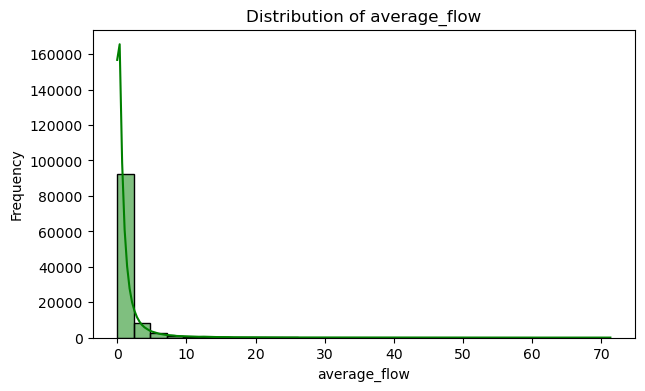

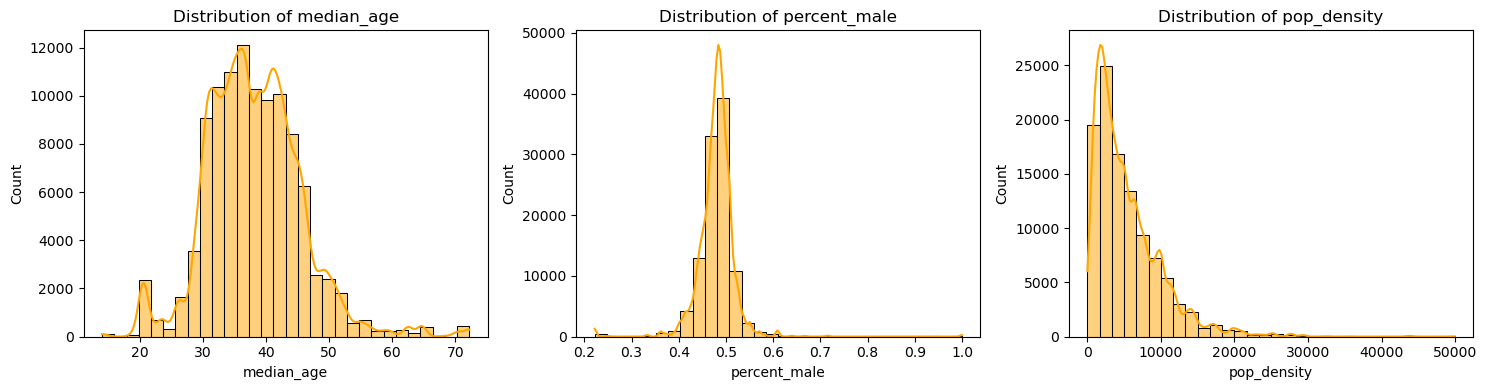

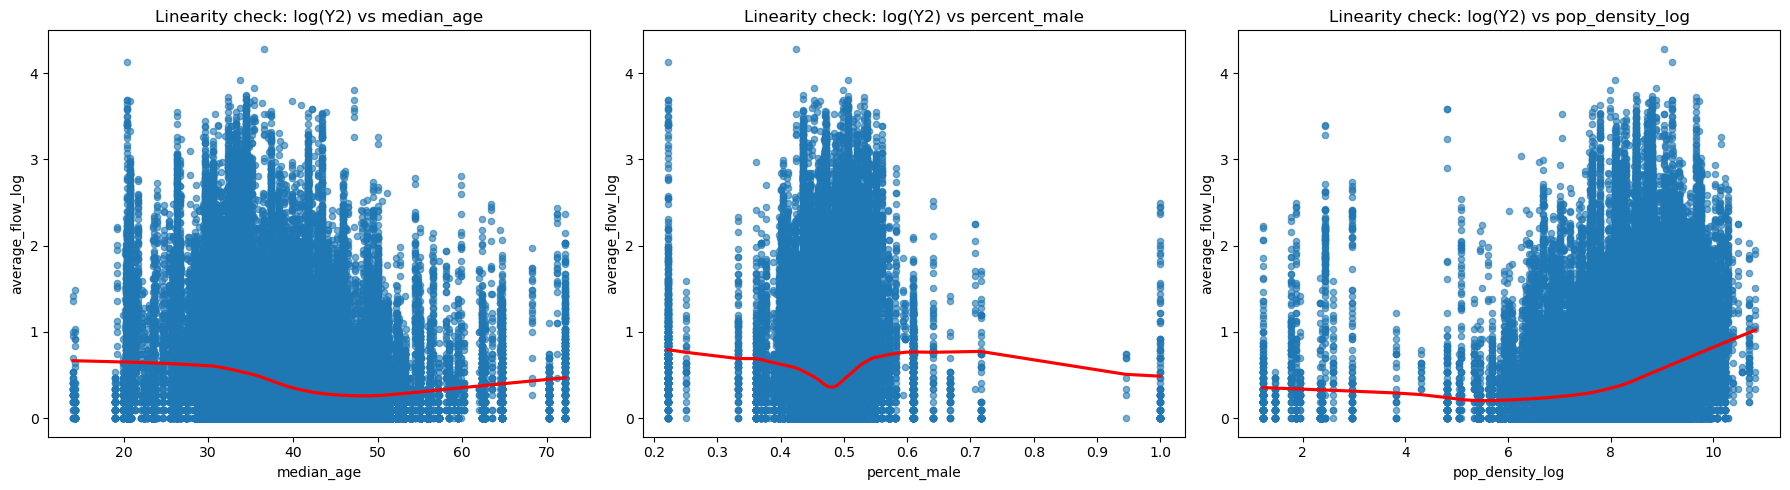

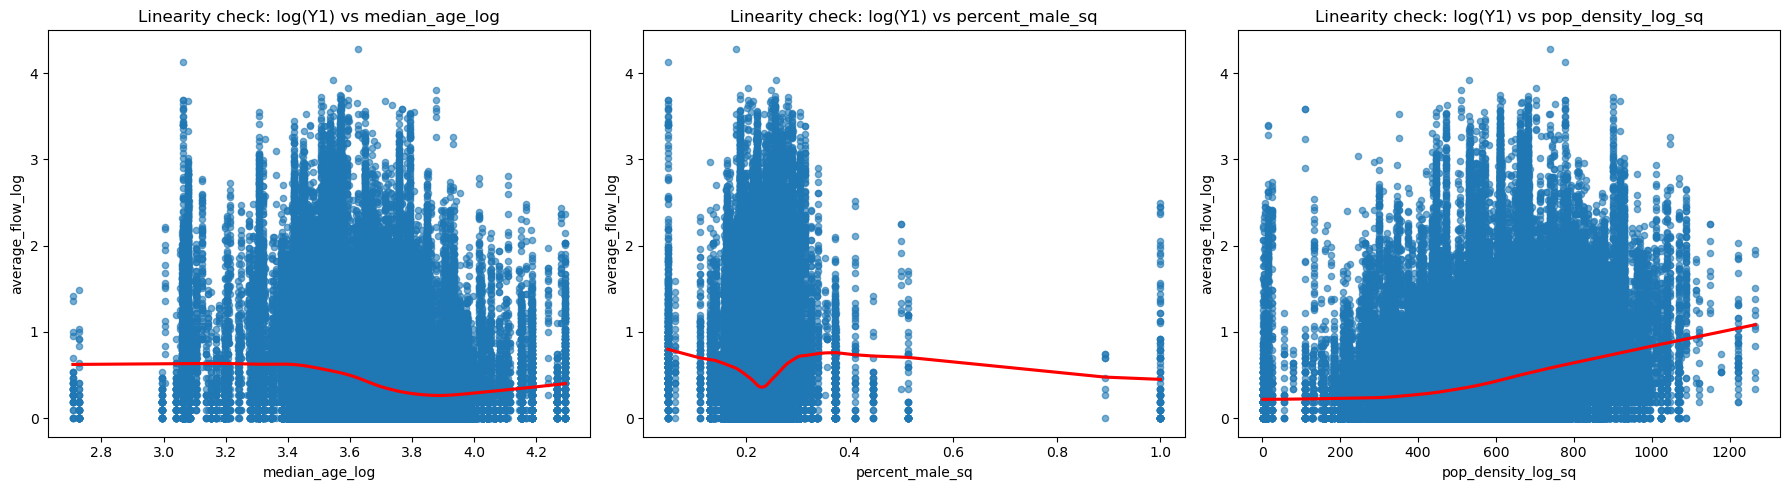

                            OLS Regression Results                            
Dep. Variable:       average_flow_log   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     3340.
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:22:38   Log-Likelihood:                -89739.
No. Observations:              105918   AIC:                         1.795e+05
Df Residuals:                  105914   BIC:                         1.795e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4119      0

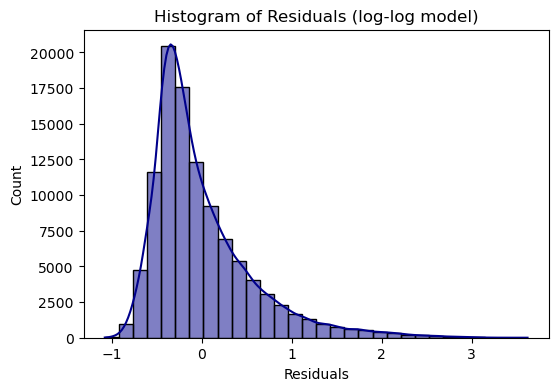

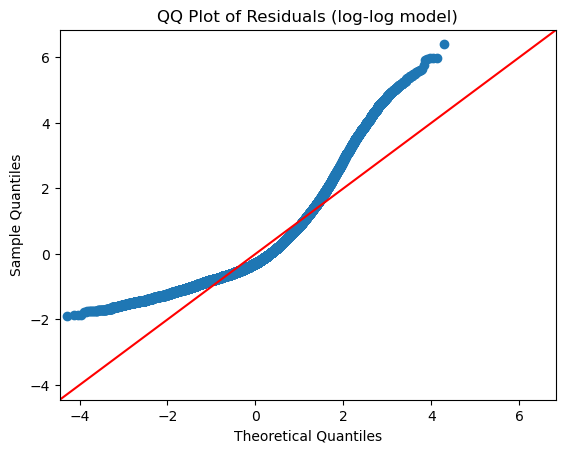

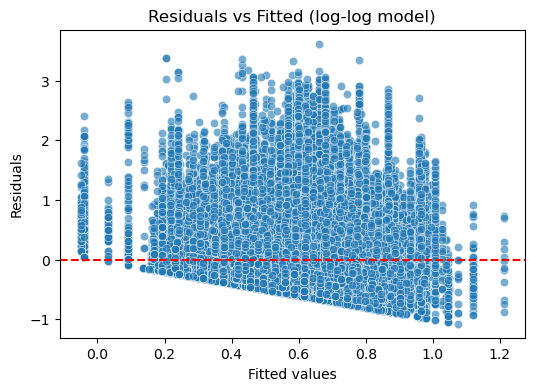

In [73]:

# 1.show the distribution of Y2, X1, X2, X3

plt.figure(figsize=(7,4))
sns.histplot(df['average_flow'], kde=True, bins=30, color='green')
plt.title('Distribution of average_flow')
plt.xlabel('average_flow')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(15,4))
for i, col in enumerate(['median_age', 'percent_male', 'pop_density']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True, bins=30, color='orange')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 2. transform Y2 and X3 into log(Y2) and log(X3)
df["average_flow_log"] = np.log1p(df["average_flow"])     
df["pop_density_log"] = np.log1p(df["pop_density"])

# 3. check linearity (scatter plot and regression line)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot = ["median_age", "percent_male", "pop_density_log"]

for i, var in enumerate(vars_to_plot):
    sns.regplot(x=var, y="average_flow_log", data=df,
                lowess=True,
                ax=axes[i], scatter_kws={"s":20, "alpha":0.6},
                line_kws={"color":"red"})
    axes[i].set_title(f"Linearity check: log(Y2) vs {var}")

plt.tight_layout()
plt.show()

# 4. transform variables accordingto the results 4
df["percent_male_sq"] = np.power(df["percent_male"], 2) 
df["pop_density_log_sq"] = np.power(df["pop_density_log"], 3) 

# 5. check linearity again (scatter plot and regression line)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot = ["median_age_log", "percent_male_sq", "pop_density_log_sq"]

for i, var in enumerate(vars_to_plot):
    sns.regplot(x=var, y="average_flow_log", data=df,
                lowess=True,
                ax=axes[i], scatter_kws={"s":20, "alpha":0.6},
                line_kws={"color":"red"})
    axes[i].set_title(f"Linearity check: log(Y1) vs {var}")

plt.tight_layout()
plt.show()

# 6. establish a multiple linear regression model about log(Y2) and log(X3)）
X = df[["median_age", "percent_male_sq", "pop_density_log_sq"]]
X = sm.add_constant(X) 
Y2_log = df["average_flow_log"]

model_loglog = sm.OLS(Y2_log, X).fit()
print(model_loglog.summary())


# 7. check normality (residuals: histogram and Q–Q plot)
residuals = model_loglog.resid
fitted = model_loglog.fittedvalues

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, color='darkblue', bins=30)
plt.title("Histogram of Residuals (log-log model)")
plt.xlabel("Residuals")
plt.show()

sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ Plot of Residuals (log-log model)")
plt.show()

# 8. check homoscedasticity
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (log-log model)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()









